In [2]:
from casadi import *
import numpy as np
import scipy

In [3]:
x = MX.sym('x', 2);  # Two states (position, velocity)
u = MX.sym('u', 1)
A = DM([[0,1], [-1,0]]) # A matrix of armonic oscillator
B = DM([[0], [1]])

print(A, B)
rhs = mtimes(A,x) + mtimes(B,u)

te = 20 # simulation end time
dt = 0.01 # how often to save results of state trajectory
tn = np.linspace(0., te, int(te/dt))

ctrl_seq = scipy.signal.unit_impulse(shape=tn.size, idx='mid') * -100.

print(rhs)

ode = {}         # ODE declaration
ode['x'] = x   # states
ode['u'] = u
ode['ode'] = rhs # right-hand side

# Construct a Function that integrates over tn
# if the second float parameter is a scalar, it is treated as the end time of the simulation (tf)
# if it is an array, each value an instant in which the output is recorded
# https://web.casadi.org/python-api/#integrator
# this is not very clear from the docs
opts = {}
F = integrator('F','cvodes',ode, 0, tn ,opts)


# Integrate with initial conditions x=[0;1]
res = F(x0=[0,1], u=ctrl_seq)

print(res)



[[0, 1], 
 [-1, 0]] [0, 1]
(mac(
[[0, 1], 
 [-1, 0]],x,zeros(2x1))+([0, 1]*u))
{'adj_p': DM(0x0), 'adj_u': DM(0x0), 'adj_x0': DM(0x0), 'adj_z0': DM(0x0), 'qf': DM(0x2000), 'xf': DM(
[[0, 0.0100048, 0.0200087, ..., 1.43196, 1.44466, 1.45722], 
 [1, 0.99995, 0.9998, ..., 1.27643, 1.26204, 1.24752]]), 'zf': DM(0x2000)}


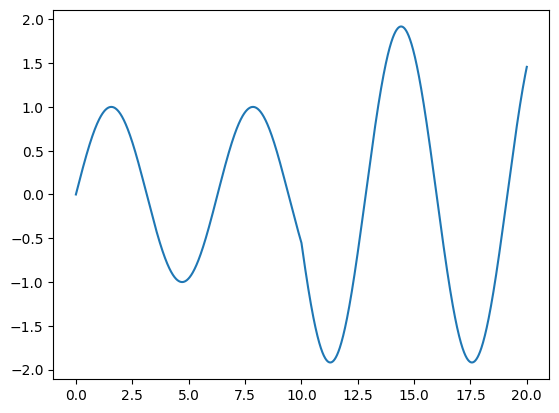

In [4]:
import matplotlib.pyplot as plt

x = res['xf'][0,:].T
fig, ax = plt.subplots()
ax.plot(tn, x)